# Experiment 3 — Boosting Ensemble (XGBoost + LightGBM + CatBoost)

**Goal:** Beat 90% accuracy on Y-chromosome super-population classification.

**Strategy:**
- Tune XGBoost, LightGBM, and CatBoost independently with Optuna (100 trials each)
- Average their softmax probabilities (soft voting ensemble)
- Train final models on train+val combined
- Class imbalance handled via `sample_weight` (inverse frequency)

## 0. Imports

In [1]:
import csv
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

try:
    import xgboost as xgb
    print(f"XGBoost  {xgb.__version__} OK")
except ImportError:
    raise ImportError("Run: pip3 install xgboost")

try:
    import lightgbm as lgb
    print(f"LightGBM {lgb.__version__} OK")
except ImportError:
    raise ImportError("Run: pip3 install lightgbm")

try:
    from catboost import CatBoostClassifier
    import catboost
    print(f"CatBoost {catboost.__version__} OK")
except ImportError:
    raise ImportError("Run: pip3 install catboost")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f"Optuna   {optuna.__version__} OK")
except ImportError:
    raise ImportError("Run: pip3 install optuna")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE    = "/Users/aaditya/VS Code/1000 genome project"
VCF_CSV = f"{BASE}/Data/vcf_table.csv"
PANEL   = f"{BASE}/integrated_call_samples_v3.20130502.ALL.panel"
OUT_DIR = f"{BASE}/Output "

print("All imports OK.")

XGBoost  3.2.0 OK
LightGBM 4.6.0 OK
CatBoost 1.2.10 OK
Optuna   4.7.0 OK
All imports OK.


## 1. Load & Preprocess Genotype Data

In [2]:
with open(VCF_CSV, 'r', encoding='utf-8', errors='replace') as f:
    sample_text = ''.join([next(f) for _ in range(20)])
dialect = csv.Sniffer().sniff(sample_text, delimiters=[',', '\t', ';', '|'])
sep = dialect.delimiter

df = pd.read_csv(VCF_CSV, sep=sep, header=0, low_memory=False)
df.columns = [c.strip().lstrip('\ufeff') for c in df.columns]

FIXED_COLS = {'#CHROM','CHROM','POS','ID','REF','ALT','QUAL','FILTER','INFO','FORMAT'}
sample_cols = [c for c in df.columns if c not in FIXED_COLS]
print(f"Variants (raw): {len(df):,} | Samples: {len(sample_cols):,}")

qual = pd.to_numeric(df.get('QUAL'), errors='coerce')
filter_cols = [c for c in df.columns if c.strip().upper() == 'FILTER']
if filter_cols:
    df = df[(df[filter_cols[0]].astype(str).str.upper() == 'PASS') & (qual > 30)].copy()
else:
    df = df[qual > 30].copy()
df = df[~df['ALT'].astype(str).str.contains(',', na=False)].copy()

G = df[sample_cols].replace(
    {'.': pd.NA, './.': pd.NA, '0|0': 0, '1|1': 1,
     '0/0': 0, '1/1': 1, '0': 0, '1': 1}
)
G = G.apply(pd.to_numeric, errors='coerce')

male_samples = list((1 - G.isna().mean())[lambda s: s > 0.05].index)
Gm = G[male_samples]

qual_clean    = pd.to_numeric(df.get('QUAL'), errors='coerce').reindex(Gm.index)
var_call_rate = 1 - Gm.isna().mean(axis=1)
keep          = (var_call_rate >= 0.95) & (qual_clean >= 30)
Gm_clean      = Gm.loc[keep]

sample_missing = Gm_clean.isna().mean()
Gm_clean = Gm_clean.drop(columns=sample_missing[sample_missing > 0.1].index)

print(f"Variants after QC: {Gm_clean.shape[0]:,} | Males: {Gm_clean.shape[1]:,}")

Variants (raw): 62,042 | Samples: 1,233
Variants after QC: 60,789 | Males: 1,233


## 2. Feature Matrix & Labels

In [3]:
X_raw = Gm_clean.T

panel = pd.read_csv(PANEL, sep='\t', usecols=['sample', 'super_pop'])
panel = panel.rename(columns={'super_pop': 'label'})
panel = panel[panel['sample'].isin(X_raw.index)].set_index('sample')
X_raw = X_raw.loc[panel.index]

y_str     = panel['label'].to_numpy(dtype=str)
X_imputed = X_raw.fillna(0).values.astype(np.float32)

le = LabelEncoder()
y  = le.fit_transform(y_str)

print(f"Feature matrix : {X_imputed.shape}")
print(f"Classes        : {le.classes_}")
print(f"Distribution   : {Counter(y_str)}")

Feature matrix : (1233, 60789)
Classes        : ['AFR' 'AMR' 'EAS' 'EUR' 'SAS']
Distribution   : Counter({np.str_('AFR'): 319, np.str_('SAS'): 260, np.str_('EAS'): 244, np.str_('EUR'): 240, np.str_('AMR'): 170})


## 3. PCA — 300 Components

In [4]:
N_COMPONENTS = 300

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca   = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled).astype(np.float32)

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance explained by {N_COMPONENTS} PCs: {cum_var[-1]*100:.1f}%")
print(f"PCA output shape: {X_pca.shape}")

Variance explained by 300 PCs: 64.9%
PCA output shape: (1233, 300)


## 4. Train / Validation / Test Split (70 / 15 / 15)

In [5]:
X_pca_np = np.array(X_pca, dtype=np.float32)
y_np     = np.array(y,     dtype=np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_pca_np, y_np, test_size=0.15, stratify=y_np, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=round(0.15 / 0.85, 4), stratify=y_trainval, random_state=RANDOM_STATE
)

# Inverse-frequency sample weights for class imbalance
_counts       = np.bincount(y_train)
_inv_freq     = 1.0 / _counts[y_train]
sample_weight = _inv_freq / _inv_freq.mean()

# Weights for full train+val set (used during final model training)
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])
_c_full  = np.bincount(y_full)
sw_full  = (1.0 / _c_full[y_full])
sw_full  = sw_full / sw_full.mean()

N_CLASSES = len(le.classes_)
CV5       = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")
print(f"Full  : {len(X_full)} (train+val for final training)")
print(f"Classes: {le.classes_}")

Train : 863 | Val : 185 | Test : 185
Full  : 1048 (train+val for final training)
Classes: ['AFR' 'AMR' 'EAS' 'EUR' 'SAS']


## 5. Optuna Tuning — XGBoost

In [6]:
def cv_score(clf, X, y, sw):
    """Manual 5-fold CV with sample_weight — works on all sklearn versions."""
    scores = []
    for tr, va in CV5.split(X, y):
        clf.fit(X[tr], y[tr], sample_weight=sw[tr])
        scores.append(accuracy_score(y[va], clf.predict(X[va])))
    return np.mean(scores)


def xgb_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 2000),
        max_depth         = trial.suggest_int('max_depth', 2, 7),
        learning_rate     = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.4, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.3, 1.0),
        colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.3, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 15),
        gamma             = trial.suggest_float('gamma', 0.0, 2.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    )
    clf = xgb.XGBClassifier(
        **p, objective='multi:softprob', num_class=N_CLASSES,
        eval_metric='mlogloss', tree_method='hist',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    return cv_score(clf, X_train, y_train, sample_weight)


print("Tuning XGBoost (100 trials)...")
xgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(),
)
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)
xgb_best = xgb_study.best_params
print(f"XGBoost best CV acc: {xgb_study.best_value*100:.2f}%")
print(f"Best params: {xgb_best}")

Tuning XGBoost (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]

XGBoost best CV acc: 84.13%
Best params: {'n_estimators': 499, 'max_depth': 4, 'learning_rate': 0.007483676326189253, 'subsample': 0.842261621371965, 'colsample_bytree': 0.3338855144969958, 'colsample_bylevel': 0.33981608238980715, 'min_child_weight': 7, 'gamma': 0.7192646974463079, 'reg_alpha': 0.026643812827786953, 'reg_lambda': 2.7600447861247823}


## 6. Optuna Tuning — LightGBM

In [7]:
def lgb_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 2000),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 15, 150),
        subsample         = trial.suggest_float('subsample', 0.4, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.3, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    )
    clf = lgb.LGBMClassifier(
        **p, objective='multiclass', num_class=N_CLASSES,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    )
    return cv_score(clf, X_train, y_train, sample_weight)


print("Tuning LightGBM (100 trials)...")
lgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(),
)
lgb_study.optimize(lgb_objective, n_trials=100, show_progress_bar=True)
lgb_best = lgb_study.best_params
print(f"LightGBM best CV acc: {lgb_study.best_value*100:.2f}%")
print(f"Best params: {lgb_best}")

Tuning LightGBM (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]

LightGBM best CV acc: 83.78%
Best params: {'n_estimators': 1635, 'max_depth': 7, 'learning_rate': 0.006968802545622209, 'num_leaves': 125, 'subsample': 0.7874956059317967, 'colsample_bytree': 0.918573454084011, 'min_child_samples': 16, 'reg_alpha': 0.002293511860334556, 'reg_lambda': 0.16725088571097324}


## 7. Optuna Tuning — CatBoost

In [9]:
def cat_objective(trial):
    p = dict(
        iterations        = trial.suggest_int('iterations', 200, 2000),
        depth             = trial.suggest_int('depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        l2_leaf_reg       = trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        bootstrap_type    = 'Bernoulli',   # required to use subsample
        subsample         = trial.suggest_float('subsample', 0.4, 1.0),
        colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.3, 1.0),
        min_data_in_leaf  = trial.suggest_int('min_data_in_leaf', 1, 20),
    )
    clf = CatBoostClassifier(
        **p, loss_function='MultiClass',
        random_seed=RANDOM_STATE, thread_count=-1, verbose=0,
    )
    return cv_score(clf, X_train, y_train, sample_weight)


print("Tuning CatBoost (100 trials)...")
cat_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(),
)
cat_study.optimize(cat_objective, n_trials=100, show_progress_bar=True)
cat_best = cat_study.best_params
print(f"CatBoost best CV acc: {cat_study.best_value*100:.2f}%")
print(f"Best params: {cat_best}")

Tuning CatBoost (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]

CatBoost best CV acc: 84.48%
Best params: {'iterations': 1662, 'depth': 3, 'learning_rate': 0.031054016409570773, 'l2_leaf_reg': 0.08707306830957152, 'subsample': 0.9534832676960515, 'colsample_bylevel': 0.9104644715000844, 'min_data_in_leaf': 6}


## 8. Train Final Ensemble on Train+Val

In [11]:
N_SEEDS = 5   # seeds per model type → 15 models total

final_models = {'xgb': [], 'lgb': [], 'cat': []}

print("Training XGBoost ensemble...")
for i in range(N_SEEDS):
    seed = RANDOM_STATE + i * 7
    m = xgb.XGBClassifier(
        **xgb_best, objective='multi:softprob', num_class=N_CLASSES,
        eval_metric='mlogloss', tree_method='hist',
        random_state=seed, n_jobs=-1, verbosity=0,
    )
    m.fit(X_full, y_full, sample_weight=sw_full)
    final_models['xgb'].append(m)
    print(f"  XGB {i+1}/{N_SEEDS}")

print("Training LightGBM ensemble...")
for i in range(N_SEEDS):
    seed = RANDOM_STATE + i * 7
    m = lgb.LGBMClassifier(
        **lgb_best, objective='multiclass', num_class=N_CLASSES,
        random_state=seed, n_jobs=-1, verbosity=-1,
    )
    m.fit(X_full, y_full, sample_weight=sw_full)
    final_models['lgb'].append(m)
    print(f"  LGB {i+1}/{N_SEEDS}")

print("Training CatBoost ensemble...")
for i in range(N_SEEDS):
    seed = RANDOM_STATE + i * 7
    m = CatBoostClassifier(
        **cat_best, bootstrap_type='Bernoulli',  # required when subsample is set
        loss_function='MultiClass',
        random_seed=seed, thread_count=-1, verbose=0,
    )
    m.fit(X_full, y_full, sample_weight=sw_full)
    final_models['cat'].append(m)
    print(f"  CAT {i+1}/{N_SEEDS}")

total = sum(len(v) for v in final_models.values())
print(f"\nTotal models trained: {total} ({N_SEEDS} × 3 types)")

Training XGBoost ensemble...
  XGB 1/5
  XGB 2/5
  XGB 3/5
  XGB 4/5
  XGB 5/5
Training LightGBM ensemble...
  LGB 1/5
  LGB 2/5
  LGB 3/5
  LGB 4/5
  LGB 5/5
Training CatBoost ensemble...
  CAT 1/5
  CAT 2/5
  CAT 3/5
  CAT 4/5
  CAT 5/5

Total models trained: 15 (5 × 3 types)


## 9. Evaluate — Soft Voting Ensemble

In [12]:
def ensemble_predict(models_dict, X):
    """Average softmax probabilities across all models in all groups."""
    all_probs = []
    for models in models_dict.values():
        for m in models:
            all_probs.append(m.predict_proba(X))
    return np.mean(all_probs, axis=0)


# --- Full ensemble ---
probs_full = ensemble_predict(final_models, X_test)
preds_full = np.argmax(probs_full, axis=1)
acc_full   = accuracy_score(y_test, preds_full)

# --- Per-model-type accuracy (for comparison) ---
results = {}
for name, models in final_models.items():
    probs = np.mean([m.predict_proba(X_test) for m in models], axis=0)
    acc   = accuracy_score(y_test, np.argmax(probs, axis=1))
    results[name] = acc

print("=" * 55)
print("RESULTS")
print("=" * 55)
print(f"  XGBoost  ensemble  : {results['xgb']*100:.2f}%")
print(f"  LightGBM ensemble  : {results['lgb']*100:.2f}%")
print(f"  CatBoost ensemble  : {results['cat']*100:.2f}%")
print(f"  FULL ENSEMBLE (×15): {acc_full*100:.2f}%  ← final")
print(f"  Baseline (LR)      :  86.23%")
print(f"  Improvement        : {(acc_full - 0.8623)*100:+.2f} pp")
print()
print(classification_report(y_test, preds_full, target_names=le.classes_))

RESULTS
  XGBoost  ensemble  : 87.57%
  LightGBM ensemble  : 86.49%
  CatBoost ensemble  : 89.19%
  FULL ENSEMBLE (×15): 86.49%  ← final
  Baseline (LR)      :  86.23%
  Improvement        : +0.26 pp

              precision    recall  f1-score   support

         AFR       0.94      0.96      0.95        48
         AMR       0.62      0.52      0.57        25
         EAS       0.95      1.00      0.97        37
         EUR       0.70      0.78      0.74        36
         SAS       1.00      0.92      0.96        39

    accuracy                           0.86       185
   macro avg       0.84      0.84      0.84       185
weighted avg       0.86      0.86      0.86       185



## 10. Confusion Matrix & Plots

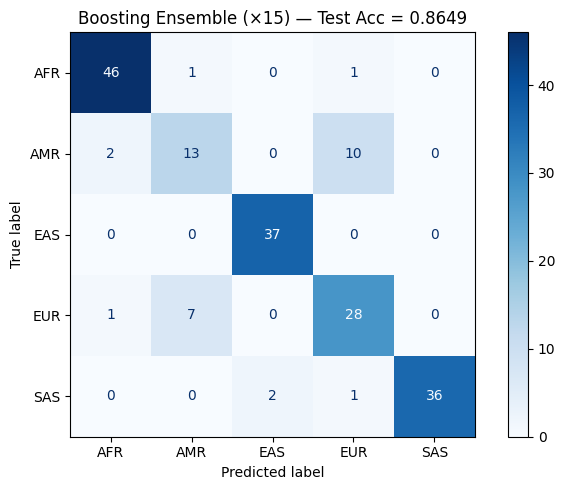

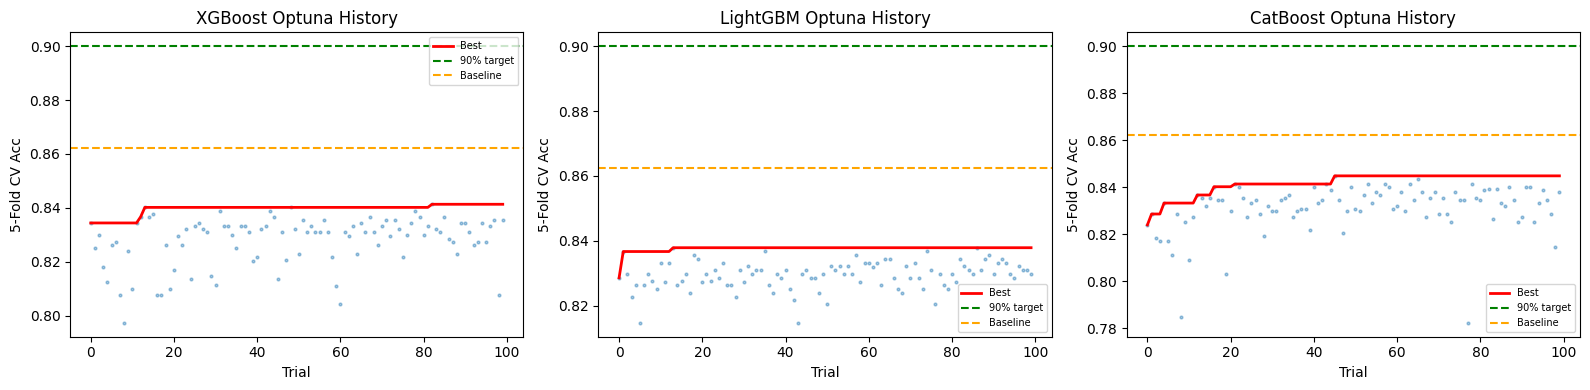

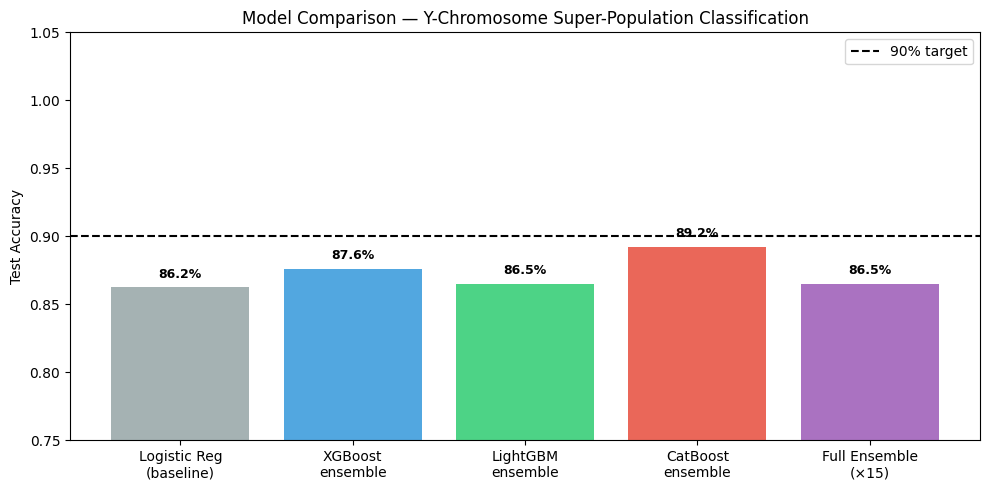

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, preds_full)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap='Blues')
ax.set_title(f"Boosting Ensemble (×15) — Test Acc = {acc_full:.4f}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp3_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Optuna history for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, study, name in zip(axes,
                            [xgb_study, lgb_study, cat_study],
                            ['XGBoost', 'LightGBM', 'CatBoost']):
    df_t = study.trials_dataframe()
    ax.plot(df_t['number'], df_t['value'], '.', alpha=0.4, markersize=4)
    ax.plot(df_t['number'], df_t['value'].cummax(), 'r-', linewidth=2, label='Best')
    ax.axhline(y=0.90,   color='green',  linestyle='--', label='90% target')
    ax.axhline(y=0.8623, color='orange', linestyle='--', label='Baseline')
    ax.set_title(f'{name} Optuna History')
    ax.set_xlabel('Trial'); ax.set_ylabel('5-Fold CV Acc')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp3_optuna_history.png", dpi=150, bbox_inches='tight')
plt.show()

# Model comparison bar chart
comp = {
    'Logistic Reg\n(baseline)': 0.8623,
    'XGBoost\nensemble': results['xgb'],
    'LightGBM\nensemble': results['lgb'],
    'CatBoost\nensemble': results['cat'],
    'Full Ensemble\n(×15)': acc_full,
}
colors = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(comp.keys(), comp.values(), color=colors, alpha=0.85)
ax.axhline(y=0.90, color='black', linestyle='--', linewidth=1.5, label='90% target')
ax.set_ylim(0.75, 1.05)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison — Y-Chromosome Super-Population Classification')
for bar, val in zip(bars, comp.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val*100:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp3_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Models

In [14]:
save_path = f"{BASE}/Output /exp3_boosting_ensemble.pkl"
joblib.dump({
    'models':                final_models,
    'xgb_best_params':       xgb_best,
    'lgb_best_params':       lgb_best,
    'cat_best_params':       cat_best,
    'xgb_cv_acc':            xgb_study.best_value,
    'lgb_cv_acc':            lgb_study.best_value,
    'cat_cv_acc':            cat_study.best_value,
    'label_encoder_classes': le.classes_,
    'pca_n_components':      N_COMPONENTS,
    'test_accuracy':         float(acc_full),
    'per_model_accuracy':    results,
}, save_path)

print(f"Saved → {save_path}")
print(f"Final test accuracy: {acc_full:.4f}  ({acc_full*100:.2f}%)")

Saved → /Users/aaditya/VS Code/1000 genome project/Output /exp3_boosting_ensemble.pkl
Final test accuracy: 0.8649  (86.49%)
